In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from scipy.optimize import curve_fit
from sklearn.linear_model import LinearRegression
from sklearn.utils import resample
from scipy.stats import mannwhitneyu
from scipy.stats import wilcoxon

plt.style.use('tableau-colorblind10')
plt.rcParams.update({'font.size': 18, 'font.family':'Arial'})

In [11]:
mags  = pd.read_csv('MAGs_rarified_pangenome_sizes.csv')
isolates  = pd.read_csv('isolates_rarified_pangenome_sizes.csv')

mags.head()

,species,num_genomes,rep_number,centroid_90,centroid_99
0,783244,15,3,1807,6110
1,783244,15,7,1838,6287
2,783244,15,4,1830,5767
3,783244,15,9,1712,5367
4,783244,17,3,1992,6341


In [12]:
sp_list = mags['species'].unique()

In [13]:

base_dir = '/Users/cdubin/Box/VMGC_cervical_dysplasia_paper/code/'
mapping = pd.read_csv(f'{base_dir}/compare_VMGC_GTDB/MIDAS_VMGC_species_mapping.csv')
vmgc_to_species = mapping.drop_duplicates('VMGC_species_id').set_index('VMGC_species_id')['VMGC_species'].to_dict()
vmgc_to_GTDB = mapping.drop_duplicates('VMGC_species_id').set_index('VMGC_species_id')['MIDAS_species_id'].to_dict()

In [14]:
def power_func(x, a, b):
    return a * (x ** b)

In [15]:
species_order = ['Lactobacillus crispatus',
                                'Lactobacillus iners',
                                'Lactobacillus jensenii',
                                'Lactobacillus gasseri',
                                'Bifidobacterium vaginale',
                                'Fannyhessea vaginae']

sp_code_order= mapping.drop_duplicates('MIDAS_GTDB_species').set_index('MIDAS_GTDB_species').loc[species_order]['VMGC_species_id'].tolist()
sp_code_order                        

[988598, 240891, 571325, 611554, 783244, 619501]

In [16]:
import matplotlib
matplotlib.rcParams["text.usetex"] = False


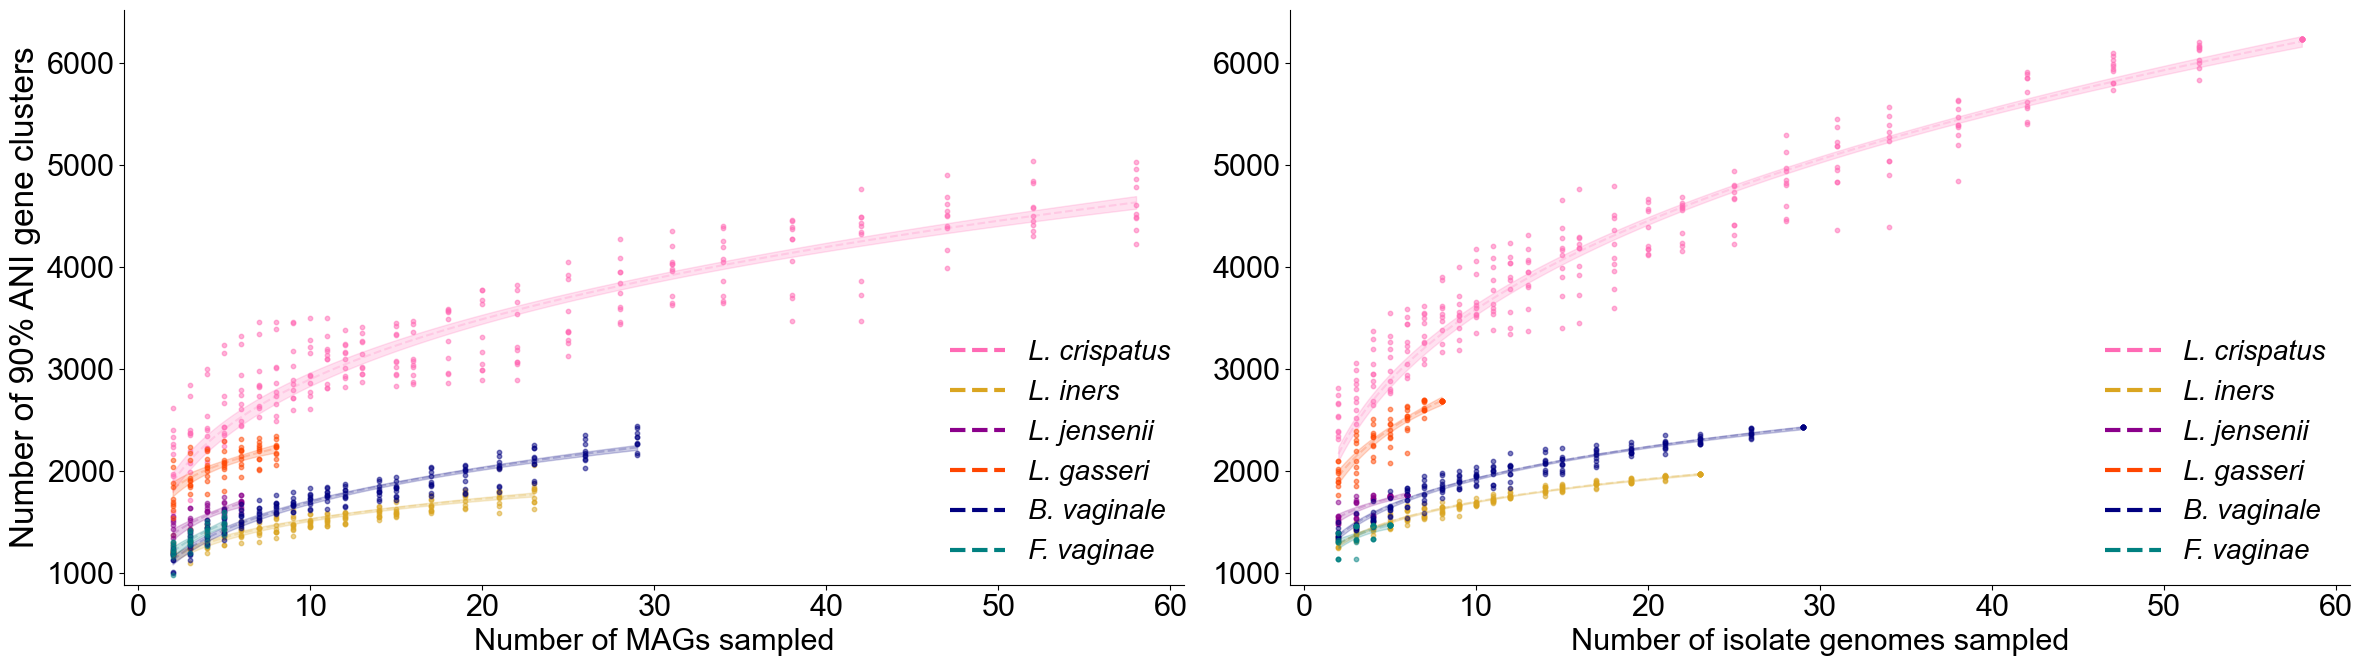

In [21]:

# colors = plt.cm.tab10(np.linspace(0, 1, 10))
fig, axs = plt.subplots(1,2, figsize=(24, 7), )
colors = ['hotpink', 'goldenrod','darkmagenta','orangered',  'navy', 'teal']

for j, counts in enumerate([mags, isolates]):

    ax = axs[j]

    for i, sp in enumerate(sp_code_order):
        
        temp = counts[counts['species'] == sp]
        temp = temp.sort_values('num_genomes')
        x = temp['num_genomes'].values
        y = temp['centroid_90'].values

        # Sort x for plotting fits
        x_sorted = np.linspace(min(x), max(x), 100)

        # Use inverse variance or custom weights
        weights = 1 / (x ** 0.5)

        popt, pcov = curve_fit(power_func, x, y, sigma=weights, absolute_sigma=False)


        # Fit power curve
        # popt, pcov = curve_fit(power_func, x, y, p0=[1, 1])
        a_fit, b_fit = popt
        perr = np.sqrt(np.diag(pcov))
        a_se, b_se = perr

        # Generate smooth x values for plotting the fit
        x_fit = np.linspace(min(x), max(x), 1000)
        y_fit = power_func(x_fit, a_fit, b_fit)

        # Error propagation to compute standard error of the predicted y values
        # dy/da = x^b, dy/db = a * x^b * ln(x)
        J0 = x_fit ** b_fit
        J1 = a_fit * (x_fit ** b_fit) * np.log(x_fit)
        var_y_fit = (J0 ** 2) * pcov[0, 0] + (J1 ** 2) * pcov[1, 1] + 2 * J0 * J1 * pcov[0, 1]
        y_se = np.sqrt(var_y_fit)


        # Compute 95% confidence interval
        # Approximate using error propagation
        # dy/da = x^b, dy/db = a * x^b * ln(x)
        J0 = x_fit ** b_fit  # ∂y/∂a
        J1 = a_fit * (x_fit ** b_fit) * np.log(x_fit)  # ∂y/∂b
        var_y_fit = (J0 ** 2) * pcov[0, 0] + (J1 ** 2) * pcov[1, 1] + 2 * J0 * J1 * pcov[0, 1]
        y_err = 1.96 * np.sqrt(var_y_fit)  # 95% CI (Z = 1.96)

        # Plotting
        xmax_idx = np.argmax(x)
        # color = colors[i % len(colors)]
        label = f'{vmgc_to_species[int(sp)]}'

        label = f"{vmgc_to_species[int(sp)]}"
        label = label.split(' ')[0][0] +'. ' +label.split(' ')[1]
        safe_label = label.replace(" ", r"\ ")

        ax.plot(x_fit, y_fit, label = label, color=colors[i], alpha=0.2, linestyle='--')


        ax.fill_between(x_fit, y_fit - y_err, y_fit + y_err, color=colors[i], alpha=0.2)


        ax.scatter(x, y, color=colors[i], marker='o', s=10, alpha=0.5)


    # ax.set_xlabel("Number of genomes sampled", fontsize=20)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

axs[0].set_ylabel("Number of 90% ANI gene clusters", fontsize=24)
axs[0].set_xlim(axs[1].get_xlim())
axs[0].set_ylim(axs[1].get_ylim())
axs[0].tick_params(axis='both', which='major', labelsize=22)
axs[1].tick_params(axis='both', which='major', labelsize=22)
# axs[0].set_ylabel("", fontsize=20)
axs[0].set_xlabel("Number of MAGs sampled", fontsize=22)
axs[1].set_xlabel("Number of isolate genomes sampled", fontsize=22)


# handles, labels = ax.get_legend_handles_labels()

leg = axs[0].legend(frameon=False, fontsize=20, ncols=1, handlelength=2,
        bbox_to_anchor=(1.01,0.47), 
        columnspacing=1)
for line in leg.get_lines():
    line.set_linewidth(3.0)
    line.set_alpha(1)
for text in leg.get_texts():
    text.set_fontstyle("italic") 

leg = axs[1].legend(frameon=False, fontsize=20, ncols=1, handlelength=2,
        bbox_to_anchor=(1,0.47), 
        columnspacing=1)
for line in leg.get_lines():
    line.set_linewidth(3.0)
    line.set_alpha(1)
for text in leg.get_texts():
    text.set_fontstyle("italic") 

# axs[0].set_title('MAGs (FRT only)')
# axs[1].set_title('Isolates (FRT only)')

plt.tight_layout()
plt.subplots_adjust(wspace=0.1)
fig_dir = '/Users/cdubin/Box/VMGC_cervical_dysplasia_paper/figures/'
plt.savefig(f'{fig_dir}/figure_S5AB.png', format='png', dpi=600, bbox_inches="tight")

plt.show()


### Compare curves

In [9]:
def get_tail_slope(df, num_points=5):

    num_genomes = df['num_genomes'].sort_values(ascending=False).unique()
    to_extract = num_genomes[1:num_points+1]
    temp = df[df['num_genomes'].isin(to_extract)]
    model = LinearRegression().fit(temp['num_genomes'].values.reshape(-1, 1), temp['centroid_90'].values)
    return model.coef_[0]  # slope

In [10]:
slopes = {}
for sp in mags['species'].unique():

    if sp not in isolates['species'].values:
        continue

    mags_temp = mags[mags['species']==sp]
    # vmgc_temp['database'] = 'VMGC'
    isolates_temp = isolates[isolates['species']==sp]
    # gtdb_temp['database'] = 'GTDB'

    slopes[vmgc_to_species[sp]] = [get_tail_slope(mags_temp), get_tail_slope(isolates_temp)]

df = pd.DataFrame.from_dict(slopes, columns=['MAGs', 'isolates'], orient='index')
df['magnitude_diff'] = df['isolates'] / df['MAGs']
df


,MAGs,isolates,magnitude_diff
Bifidobacterium vaginale,33.253689,24.517623,0.737290
Lactobacillus jensenii,80.410000,68.580000,0.852879
Fannyhessea vaginae,92.300000,70.950000,0.768689
Lactobacillus gasseri,55.510000,118.390000,2.132769
Lactobacillus iners,26.175000,17.918902,0.684581
Lactobacillus crispatus,32.897146,52.468602,1.594929


In [11]:
wilcoxon(df['MAGs'].values, df['isolates'].values)

WilcoxonResult(statistic=np.float64(10.0), pvalue=np.float64(1.0))

In [12]:
mags_means = mags.groupby(['species', 'num_genomes'])['centroid_90'].agg(
    centroid_90_mean_MAGs='mean',
    centroid_90_min_MAGs='min',
    centroid_90_max_MAGs='max'
).reset_index()
mags_max = mags_means.sort_values('num_genomes', ascending=False).drop_duplicates('species')
mags_max


,species,num_genomes,centroid_90_mean_MAGs,centroid_90_min_MAGs,centroid_90_max_MAGs
77,988598,58,4629.9,4219,5030
51,783244,29,2304.4,2161,2443
16,240891,23,1799.4,1627,2059
28,611554,8,2213.7,2056,2338
21,571325,6,1686.2,1584,1763
32,619501,5,1494.3,1371,1603


In [13]:
isolates_max = isolates.sort_values('num_genomes', ascending=False).drop_duplicates('species')

In [14]:
compare_maxes = mags_max.merge(isolates_max, on=['species','num_genomes'])
compare_maxes = compare_maxes.rename(columns={'centroid_90': 'centroid_90_isolates'})

compare_maxes['is_within_range'] = (
    (compare_maxes['centroid_90_isolates'] >= compare_maxes['centroid_90_min_MAGs']) & 
    (compare_maxes['centroid_90_isolates'] <= compare_maxes['centroid_90_max_MAGs'])
)
compare_maxes['species_name'] = compare_maxes['species'].map(vmgc_to_species)

cols_to_show = [
    'species','species_name', 'num_genomes', 'centroid_90_mean_MAGs', 
    'centroid_90_min_MAGs', 'centroid_90_max_MAGs', 
    'centroid_90_isolates', 'is_within_range'
]

compare_maxes[cols_to_show]

,species,species_name,num_genomes,centroid_90_mean_MAGs,centroid_90_min_MAGs,centroid_90_max_MAGs,centroid_90_isolates,is_within_range
0,988598,Lactobacillus crispatus,58,4629.9,4219,5030,6227,False
1,783244,Bifidobacterium vaginale,29,2304.4,2161,2443,2429,True
2,240891,Lactobacillus iners,23,1799.4,1627,2059,1966,True
3,611554,Lactobacillus gasseri,8,2213.7,2056,2338,2682,False
4,571325,Lactobacillus jensenii,6,1686.2,1584,1763,1761,True
5,619501,Fannyhessea vaginae,5,1494.3,1371,1603,1468,True
